# Cloud Shadow Detection — v3: vectorized projection

Builds on `Cloud_Shadows_v2_height.ipynb` (step 1 — cloud-height fix). The only new change is performance: replace the per-pixel Python loop with vectorized NumPy operations.

| Step | Debug / v2_height | This notebook |
|---|---|---|
| Height per source pixel | scalar call in `for` loop | one NumPy call for the full grid |
| Projection (shadow lat/lon) | scalar `tan/sin/cos` per pixel | one NumPy call over all source pixels |
| Nearest-pixel search | `np.argmin` over full granule, per source pixel (O(N·M)) | single batched `scipy.spatial.cKDTree.query` (O(N log M)) |
| Bresenham line drawing | per-source loop | per-source loop (inherently iterative) |

**Behavior change (one):** in Debug, source pixels with NaN angles produced NaN shadow coordinates whose `argmin` silently returned `(0, 0)`, drawing a spurious line. Here, those source pixels are dropped and counted (`n_dropped_angles`). This is a small fix unrelated to the height step; it's documented because it cannot be avoided once `cKDTree` is in use (the tree rejects NaN queries). Everything else — cloud_threshold = 0.30, line-only PCSF, ECF<0.05 ACSF surrogate, RGB orientation, shapefile export — is unchanged.

In [1]:
import numpy as np
import netCDF4 as nc
import h5py
import glob
import os
import re

from scipy.spatial import cKDTree

import geopandas as gpd
from shapely.geometry import shape
import rasterio
from rasterio.transform import from_bounds
from rasterio.features import shapes
import matplotlib.pyplot as plt

In [2]:
# === Inputs ===
input_dir = "../data/raw_l1"
l2_dir    = "../data/raw_l2_v3"
version   = "V03"
refinement       = "helen"
cloud_threshold  = 0.30
shadow_threshold = 0.05
max_files = 10
band      = "band_290_490_nm"
min_radiance = 1.0
apply_gamma  = True

# === Cloud height parameters (from step 1) ===
SAFETY_FACTOR_C = 0.5
H_SCALE_M       = 8500.0
H_CAP_M         = 16000.0
MAX_DROP_FRAC   = 0.10

# === Earth radii (DARCLOS Eqs. 6-7) ===
M_EARTH = 6378137.0
N_EARTH = 6378137.0

output_dir = f"../experiments/output_v3_vectorized_cthres{cloud_threshold}_{refinement}_st{shadow_threshold}"

nc_files = sorted(glob.glob(f"{input_dir}/*.nc"))
if not nc_files:
    raise ValueError(f"No .nc files found in {input_dir}")
print(f"{len(nc_files)} L1B files")

4 L1B files


In [3]:
def extract_timestamp_scan(filename):
    match = re.search(r'(\d{8}T\d{6}Z)_S(\d{3})G(\d{2})', filename)
    if match:
        return match.group(1), match.group(2), match.group(3)
    return None, None, None

def find_matching_l2_file(l1_file, l2_dir='L2', version="V03"):
    timestamp, scan, granule = extract_timestamp_scan(l1_file)
    if not timestamp:
        return None
    pattern = f"TEMPO_CLDO4_L2_{version}_{timestamp}_S{scan}G{granule.split('-')[0]}.nc"
    l2_path = os.path.join(l2_dir, pattern)
    if os.path.exists(l2_path):
        return l2_path
    search_pattern = os.path.join(l2_dir, f"TEMPO_CLDO4_L2_{version}_{timestamp}_S{scan}G*.nc")
    matches = glob.glob(search_pattern)
    return matches[0] if matches else None

l2_files = []
for l1_file in nc_files:
    l2_files.append(find_matching_l2_file(l1_file, l2_dir, version=version))
for l1, l2 in zip(nc_files, l2_files):
    if l2 is None:
        raise FileNotFoundError(f"No L2 match for {l1}")

In [4]:
def compute_heights_vectorized(cth, p_cloud, p_sfc, h_sfc):
    """Vectorized version of compute_effective_shadow_height (step-1 fix)."""
    b1 = np.isfinite(cth) & (cth > h_sfc)
    h_asl_b1 = np.where(b1, np.minimum(cth, H_CAP_M), np.nan)
    h_eff_b1 = (1.0 + SAFETY_FACTOR_C) * (h_asl_b1 - h_sfc)

    p_finite = np.isfinite(p_cloud) & np.isfinite(p_sfc) \
               & (p_cloud > 0) & (p_sfc > 0)
    with np.errstate(invalid="ignore", divide="ignore"):
        h_above = H_SCALE_M * np.log(p_sfc / p_cloud)
    use_b2 = p_finite & (p_sfc > p_cloud) & np.isfinite(h_above) & (h_above > 0)
    h_asl_b2 = np.where(use_b2, np.minimum(h_above + h_sfc, H_CAP_M), np.nan)
    h_eff_b2 = (1.0 + SAFETY_FACTOR_C) * (h_asl_b2 - h_sfc)

    below_sfc = p_finite & (p_sfc <= p_cloud)

    h_eff = np.full_like(h_eff_b1, np.nan)
    h_eff = np.where(b1, h_eff_b1, h_eff)
    h_eff = np.where(~b1 & use_b2, h_eff_b2, h_eff)
    h_eff = np.where(~b1 & ~use_b2 & below_sfc, 0.0, h_eff)
    h_eff = np.where(np.isfinite(h_eff) & (h_eff >= 0), h_eff, np.nan)
    return h_eff


def project_shadow_coords_vectorized(
    lat, lon, h, terrain_height,
    solar_zenith, solar_azimuth, viewing_zenith, viewing_azimuth,
    ii, jj,
):
    """Vectorized DARCLOS projection (Trees et al. 2022, Eqs. 2-7)."""
    theta0 = np.radians(solar_zenith[ii, jj])
    phi0   = np.radians(solar_azimuth[ii, jj])
    theta  = np.radians(viewing_zenith[ii, jj])
    phi    = np.radians(viewing_azimuth[ii, jj])
    h_s    = h[ii, jj]
    h_sfc  = terrain_height[ii, jj]
    c_lat  = lat[ii, jj]
    c_lon  = lon[ii, jj]

    xn  = h_s * np.tan(theta)  * np.sin(phi)
    yn  = h_s * np.tan(theta)  * np.cos(phi)
    xsh = xn  - h_s * np.tan(theta0) * np.sin(phi0)
    ysh = yn  - h_s * np.tan(theta0) * np.cos(phi0)

    delta_lat = ysh / (M_EARTH + h_sfc)
    delta_lon = xsh / ((N_EARTH + h_sfc) * np.cos(np.radians(c_lat)))
    shadow_lat = c_lat + np.degrees(delta_lat)
    shadow_lon = c_lon + np.degrees(delta_lon)
    return shadow_lat, shadow_lon


def _load_l1b_angles(nc_file, band):
    """Read solar/viewing angles from the L1B band group.

    The DARCLOS notebook documented that L2 V03 `viewing_azimuth_angle` is
    entirely fill-valued and `solar_azimuth_angle` is ~94% fill in these
    granules. The L1B band group has all four angles fully valid and is the
    authoritative source for the projection geometry.
    """
    with nc.Dataset(nc_file) as f:
        g = f[band]
        sza = g['solar_zenith_angle'][:].filled(np.nan)
        saa = g['solar_azimuth_angle'][:].filled(np.nan)
        vza = g['viewing_zenith_angle'][:].filled(np.nan)
        vaa = g['viewing_azimuth_angle'][:].filled(np.nan)
    for name, arr in [('sza', sza), ('saa', saa), ('vza', vza), ('vaa', vaa)]:
        if int(np.isfinite(arr).sum()) == 0:
            raise ValueError(f"L1B angle '{name}' is entirely fill-valued in {nc_file}")
    return sza, saa, vza, vaa


def compute_potential_shadow_mask(nc_file, l2_file, band='band_290_490_nm',
                                   cloud_threshold=0.05):
    """Vectorized PCSF computation. Same algorithm as Debug + step-1 height fix.

    Angles are read from the L1B band group (NOT L2 geolocation) because L2 V03
    viewing/solar azimuth fields are mostly fill-valued. The Debug notebook
    silently used those fill-valued L2 angles, producing NaN shadow coordinates
    whose argmin landed on grid index (0, 0) and drew a spurious line from each
    cloud pixel to that corner — an artifact that coincidentally overlapped some
    real shadows.
    """
    with nc.Dataset(nc_file) as f:
        cloud_height = f[band]['cloud_top_height'][:].filled(fill_value=np.nan)

    solar_zenith, solar_azimuth, viewing_zenith, viewing_azimuth = \
        _load_l1b_angles(nc_file, band)

    with nc.Dataset(l2_file) as f:
        lat = f['geolocation']['latitude'][:].filled(fill_value=np.nan)
        lon = f['geolocation']['longitude'][:].filled(fill_value=np.nan)
        cloud_fraction  = f['product']['cloud_fraction'][:].filled(-999)
        terrain_height  = f['support_data']['terrain_height'][:].filled(0)
        p    = f['product']['cloud_pressure'][:].filled(np.nan)
        psfc = f['support_data']['surface_pressure'][:].filled(np.nan)

    print(f"  Cloud fraction range: {np.nanmin(cloud_fraction):.3f} to {np.nanmax(cloud_fraction):.3f}")

    cloud_mask  = cloud_fraction >= cloud_threshold
    shadow_mask = np.zeros_like(cloud_mask, dtype=bool)

    h_grid = compute_heights_vectorized(
        cth=cloud_height, p_cloud=p, p_sfc=psfc, h_sfc=terrain_height,
    )

    ii_all, jj_all = np.where(cloud_mask)
    n_total = len(ii_all)
    if n_total == 0:
        return shadow_mask, cloud_mask, cloud_fraction

    h_valid_src = np.isfinite(h_grid[ii_all, jj_all])
    n_dropped_height = int((~h_valid_src).sum())
    ii = ii_all[h_valid_src]
    jj = jj_all[h_valid_src]

    shadow_lat, shadow_lon = project_shadow_coords_vectorized(
        lat, lon, h_grid, terrain_height,
        solar_zenith, solar_azimuth, viewing_zenith, viewing_azimuth,
        ii, jj,
    )

    proj_ok = np.isfinite(shadow_lat) & np.isfinite(shadow_lon)
    n_dropped_angles = int((~proj_ok).sum())
    ii = ii[proj_ok]
    jj = jj[proj_ok]
    shadow_lat = shadow_lat[proj_ok]
    shadow_lon = shadow_lon[proj_ok]

    grid_lat = lat.ravel()
    grid_lon = lon.ravel()
    valid_grid_flat = np.isfinite(grid_lat) & np.isfinite(grid_lon)
    grid_pts = np.column_stack([grid_lat[valid_grid_flat], grid_lon[valid_grid_flat]])
    grid_idx_back = np.flatnonzero(valid_grid_flat)

    tree = cKDTree(grid_pts)
    _, nbr_idx = tree.query(np.column_stack([shadow_lat, shadow_lon]))
    flat_idx = grid_idx_back[nbr_idx]
    shadow_i, shadow_j = np.unravel_index(flat_idx, lat.shape)

    print(f"  Drawing {len(ii)} shadow lines...")

    for k in range(len(ii)):
        rr, cc = draw_line(int(ii[k]), int(jj[k]),
                           int(shadow_i[k]), int(shadow_j[k]),
                           lat.shape)
        if rr.size == 0:
            continue
        valid = ~cloud_mask[rr, cc]
        shadow_mask[rr[valid], cc[valid]] = True

    frac_h = n_dropped_height / max(n_total, 1)
    frac_a = n_dropped_angles / max(n_total, 1)
    if n_dropped_height > 0:
        print(f"  [height] dropped {n_dropped_height}/{n_total} source pixels ({frac_h:.2%}) without a valid cloud height")
    if n_dropped_angles > 0:
        print(f"  [angles] dropped {n_dropped_angles}/{n_total} source pixels ({frac_a:.2%}) with non-finite projected coordinates")
    if frac_h > MAX_DROP_FRAC:
        raise ValueError(
            f"{n_dropped_height}/{n_total} ({frac_h:.1%}) source pixels lack a valid cloud height — "
            f"exceeds MAX_DROP_FRAC = {MAX_DROP_FRAC:.1%}."
        )
    return shadow_mask, cloud_mask, cloud_fraction


def draw_line(r0, c0, r1, c1, shape):
    """Bresenham's line algorithm — unchanged from Debug notebook."""
    steep = abs(r1 - r0) > abs(c1 - c0)
    if steep:
        r0, c0 = c0, r0
        r1, c1 = c1, r1
    if c0 > c1:
        c0, c1 = c1, c0
        r0, r1 = r1, r0
    dr = abs(r1 - r0)
    dc = c1 - c0
    error = dc / 2
    rstep = 1 if r0 < r1 else -1
    rr, cc = [], []
    r = r0
    for c in range(c0, c1 + 1):
        coord_r = r if not steep else c
        coord_c = c if not steep else r
        if 0 <= coord_r < shape[0] and 0 <= coord_c < shape[1]:
            rr.append(coord_r)
            cc.append(coord_c)
        error -= dr
        if error < 0:
            r += rstep
            error += dc
    return np.array(rr), np.array(cc)


def prepare_rgb_for_visualization(nc_file, band='band_290_490_nm', apply_gamma=True):
    with nc.Dataset(nc_file) as f:
        red   = f['cloud_mask_group']['red'][:]
        green = f['cloud_mask_group']['green'][:]
        blue  = f['cloud_mask_group']['blue'][:]
    red   = np.where(red   > 1.0, 1.0, red)[:, :, np.newaxis]
    green = np.where(green > 1.0, 1.0, green)[:, :, np.newaxis]
    blue  = np.where(blue  > 1.0, 1.0, blue)[:, :, np.newaxis]
    if apply_gamma:
        red, green, blue = red ** 0.4, green ** 0.4, blue ** 0.4
    red   = np.flip(np.transpose(red,   (1, 0, 2)), axis=0)
    green = np.flip(np.transpose(green, (1, 0, 2)), axis=0)
    blue  = np.flip(np.transpose(blue,  (1, 0, 2)), axis=0)
    rgb = np.concatenate((red, green, blue), axis=2)
    rgb = np.nan_to_num(rgb, nan=0.0)
    return rgb

In [5]:
def create_shapefiles_from_masks(nc_file, l2_file, masks, output_prefix):
    print("Loading geolocation data...")
    try:
        with h5py.File(l2_file, 'r') as f:
            lat = f['geolocation']['latitude'][:]
            lon = f['geolocation']['longitude'][:]
    except Exception:
        with nc.Dataset(l2_file) as f:
            lat = f['geolocation']['latitude'][:]
            lon = f['geolocation']['longitude'][:]

    filename = os.path.basename(nc_file)
    cloud_mask_oriented     = np.flip(np.transpose(masks['cloud_mask'],     (1, 0)), axis=0)
    potential_mask_oriented = np.flip(np.transpose(masks['potential_mask'], (1, 0)), axis=0)
    actual_mask_oriented    = np.flip(np.transpose(masks['actual_mask'],    (1, 0)), axis=0)
    lon_t = np.flip(np.transpose(lon, (1, 0)), axis=0)
    lat_t = np.flip(np.transpose(lat, (1, 0)), axis=0)

    height, width = cloud_mask_oriented.shape
    west  = float(np.nanmin(lon_t)); east  = float(np.nanmax(lon_t))
    south = float(np.nanmin(lat_t)); north = float(np.nanmax(lat_t))
    print(f"  Extent: [{west:.2f}, {south:.2f}, {east:.2f}, {north:.2f}]")

    transform = from_bounds(west, south, east, north, width, height)
    shapefile_paths = {}

    def mask_to_shapefile(mask, mask_type, mask_name, output_file):
        mask_int = mask.astype(np.int32)
        mask_int = np.where(np.isnan(mask_int), 0, mask_int)
        results = list(shapes(mask_int, mask=(mask_int == 1), transform=transform))
        if len(results) == 0:
            print(f"    {mask_name}: no features")
            return None
        geometries = [shape(g) for g, _ in results]
        properties = [{'type': mask_type, 'name': mask_name, 'value': int(v),
                       'source': filename} for _, v in results]
        gdf = gpd.GeoDataFrame(properties, geometry=geometries, crs='EPSG:4326')
        gdf['area_deg2'] = gdf.geometry.area
        gdf.to_file(output_file)
        print(f"    {mask_name}: {len(gdf)} polygons -> {output_file}")
        return output_file

    for arr, mtype, mname, suffix in [
        (cloud_mask_oriented,     'cloud',            'Cloud',            'clouds'),
        (potential_mask_oriented, 'potential_shadow', 'Potential Shadow', 'potential_shadows'),
        (actual_mask_oriented,    'actual_shadow',    'Actual Shadow',    'actual_shadows'),
    ]:
        p = mask_to_shapefile(arr, mtype, mname, f"{output_prefix}_{suffix}.shp")
        if p is not None:
            shapefile_paths[suffix] = p
    return shapefile_paths


def create_shadow_detection_pipeline_with_shapefiles(nc_files, l2_files,
                                                     output_dir='shapefile_output',
                                                     band='band_290_490_nm',
                                                     cloud_threshold=0.05,
                                                     apply_gamma=True,
                                                     refinement='lamb',
                                                     shadow_threshold=0.05):
    os.makedirs(output_dir, exist_ok=True)
    results = []
    for idx, (nc_file, l2_file) in enumerate(zip(nc_files, l2_files)):
        print(f"\n{'='*80}\n  {idx+1}/{len(nc_files)}: {os.path.basename(nc_file)}\n{'='*80}")
        potential_mask, cloud_mask, cloud_fraction = compute_potential_shadow_mask(
            nc_file, l2_file, band, cloud_threshold
        )
        actual_mask = (cloud_fraction > -999) & (cloud_fraction < shadow_threshold)
        actual_mask = actual_mask * potential_mask.astype('uint')

        masks = {'cloud_mask': cloud_mask, 'potential_mask': potential_mask, 'actual_mask': actual_mask}
        base_name = os.path.splitext(os.path.basename(nc_file))[0]
        output_prefix = os.path.join(output_dir, base_name)
        shapefile_paths = create_shapefiles_from_masks(nc_file, l2_file, masks, output_prefix)

        rgb = prepare_rgb_for_visualization(nc_file, band, apply_gamma)
        potential_vis = np.flip(np.transpose(potential_mask, (1, 0)), axis=0)
        actual_vis    = np.flip(np.transpose(actual_mask,    (1, 0)), axis=0)
        cloud_vis     = np.flip(np.transpose(cloud_mask,     (1, 0)), axis=0)

        fig, axes = plt.subplots(2, 3, figsize=(20, 12))
        axes[0, 0].pcolormesh(rgb); axes[0, 0].set_title('RGB'); axes[0, 0].axis('off')
        axes[0, 1].pcolormesh(rgb * 0.6)
        axes[0, 1].pcolormesh(cloud_vis, cmap='Greys_r', alpha=0.5)
        axes[0, 1].set_title(f'Clouds ({int(cloud_mask.sum())})'); axes[0, 1].axis('off')
        axes[0, 2].pcolormesh(rgb * 0.6)
        axes[0, 2].pcolormesh(potential_vis, cmap='Greys_r', alpha=0.5)
        axes[0, 2].set_title(f'Potential ({int(potential_mask.sum())})'); axes[0, 2].axis('off')
        axes[1, 0].pcolormesh(rgb * 0.6)
        axes[1, 0].pcolormesh(actual_vis, cmap='Greys_r', alpha=0.6)
        axes[1, 0].set_title(f'Actual ({int(actual_mask.sum())})'); axes[1, 0].axis('off')
        axes[1, 1].pcolormesh(rgb * 0.5)
        axes[1, 1].pcolormesh(cloud_vis,  cmap='Reds',  alpha=0.4)
        axes[1, 1].pcolormesh(actual_vis, cmap='Blues', alpha=0.4)
        axes[1, 1].set_title('Combined'); axes[1, 1].axis('off')
        axes[1, 2].axis('off')
        info = '\n'.join(f'{k}: {os.path.basename(v)}' for k, v in shapefile_paths.items())
        axes[1, 2].text(0.05, 0.5, info, fontsize=9, family='monospace')
        plt.suptitle(base_name)
        plt.tight_layout()
        fig_path = f"{output_prefix}_visualization.png"
        plt.savefig(fig_path, dpi=150, bbox_inches='tight')
        print(f"  Visualization: {fig_path}")
        plt.show()

        results.append({
            'file': nc_file,
            'masks': masks,
            'shapefile_paths': shapefile_paths,
            'visualization': fig_path,
            'stats': {
                'n_clouds':           int(cloud_mask.sum()),
                'n_potential_shadows': int(potential_mask.sum()),
                'n_actual_shadows':    int(actual_mask.sum()),
            }
        })
    return results


  1/4: TEMPO_RAD_L1_V04_20250909T115202Z_S002G02.nc
  Cloud fraction range: -999.000 to 1.000
  Drawing 110475 shadow lines...
  [height] dropped 2799/113274 source pixels (2.47%) without a valid cloud height
Loading geolocation data...
  Extent: [-77.87, 17.26, -45.97, 60.57]
    Cloud: 1597 polygons -> ../experiments/output_v3_vectorized_cthres0.3_helen_st0.05/TEMPO_RAD_L1_V04_20250909T115202Z_S002G02_clouds.shp
    Potential Shadow: 3401 polygons -> ../experiments/output_v3_vectorized_cthres0.3_helen_st0.05/TEMPO_RAD_L1_V04_20250909T115202Z_S002G02_potential_shadows.shp


/var/folders/0j/71sn2s2j71l6q088k8_ppzsc0000gn/T/ipykernel_3249/967298460.py:38: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf['area_deg2'] = gdf.geometry.area
/var/folders/0j/71sn2s2j71l6q088k8_ppzsc0000gn/T/ipykernel_3249/967298460.py:38: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf['area_deg2'] = gdf.geometry.area
/var/folders/0j/71sn2s2j71l6q088k8_ppzsc0000gn/T/ipykernel_3249/967298460.py:38: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf['area_deg2'] = gdf.geometry.area
/var/folders/0j/71sn2s2j71l6q088k8_ppzsc0000gn/T/ipykernel_3249/1211200630.py:202: RuntimeWarning

    Actual Shadow: 668 polygons -> ../experiments/output_v3_vectorized_cthres0.3_helen_st0.05/TEMPO_RAD_L1_V04_20250909T115202Z_S002G02_actual_shadows.shp
  Visualization: ../experiments/output_v3_vectorized_cthres0.3_helen_st0.05/TEMPO_RAD_L1_V04_20250909T115202Z_S002G02_visualization.png


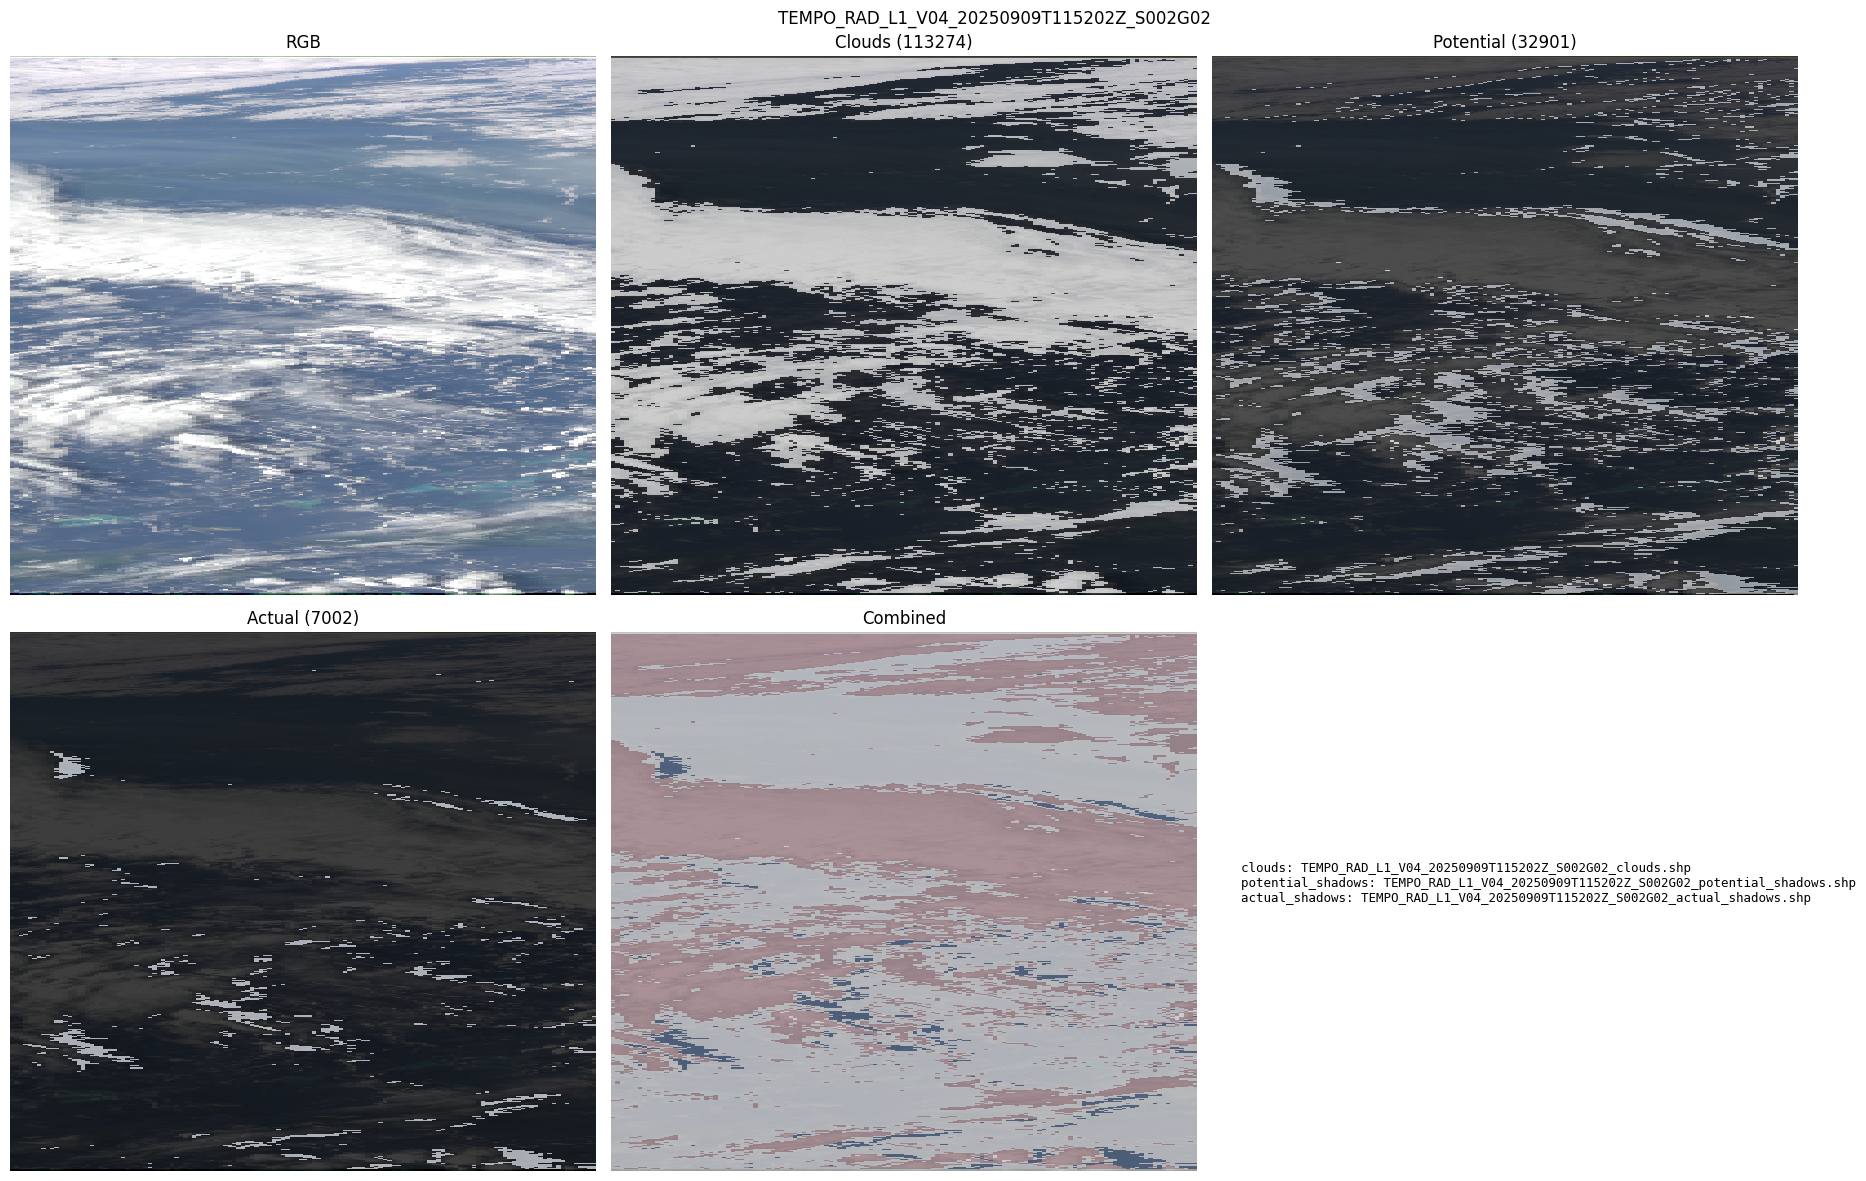


  2/4: TEMPO_RAD_L1_V04_20250909T115842Z_S002G03.nc
  Cloud fraction range: -999.000 to 1.000
  Drawing 112794 shadow lines...
  [height] dropped 2345/115139 source pixels (2.04%) without a valid cloud height
Loading geolocation data...
  Extent: [-83.76, 17.21, -64.04, 58.71]
    Cloud: 1302 polygons -> ../experiments/output_v3_vectorized_cthres0.3_helen_st0.05/TEMPO_RAD_L1_V04_20250909T115842Z_S002G03_clouds.shp
    Potential Shadow: 2509 polygons -> ../experiments/output_v3_vectorized_cthres0.3_helen_st0.05/TEMPO_RAD_L1_V04_20250909T115842Z_S002G03_potential_shadows.shp
    Actual Shadow: 715 polygons -> ../experiments/output_v3_vectorized_cthres0.3_helen_st0.05/TEMPO_RAD_L1_V04_20250909T115842Z_S002G03_actual_shadows.shp


/var/folders/0j/71sn2s2j71l6q088k8_ppzsc0000gn/T/ipykernel_3249/967298460.py:38: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf['area_deg2'] = gdf.geometry.area
/var/folders/0j/71sn2s2j71l6q088k8_ppzsc0000gn/T/ipykernel_3249/967298460.py:38: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf['area_deg2'] = gdf.geometry.area
/var/folders/0j/71sn2s2j71l6q088k8_ppzsc0000gn/T/ipykernel_3249/967298460.py:38: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf['area_deg2'] = gdf.geometry.area
/var/folders/0j/71sn2s2j71l6q088k8_ppzsc0000gn/T/ipykernel_3249/1211200630.py:202: RuntimeWarning

  Visualization: ../experiments/output_v3_vectorized_cthres0.3_helen_st0.05/TEMPO_RAD_L1_V04_20250909T115842Z_S002G03_visualization.png


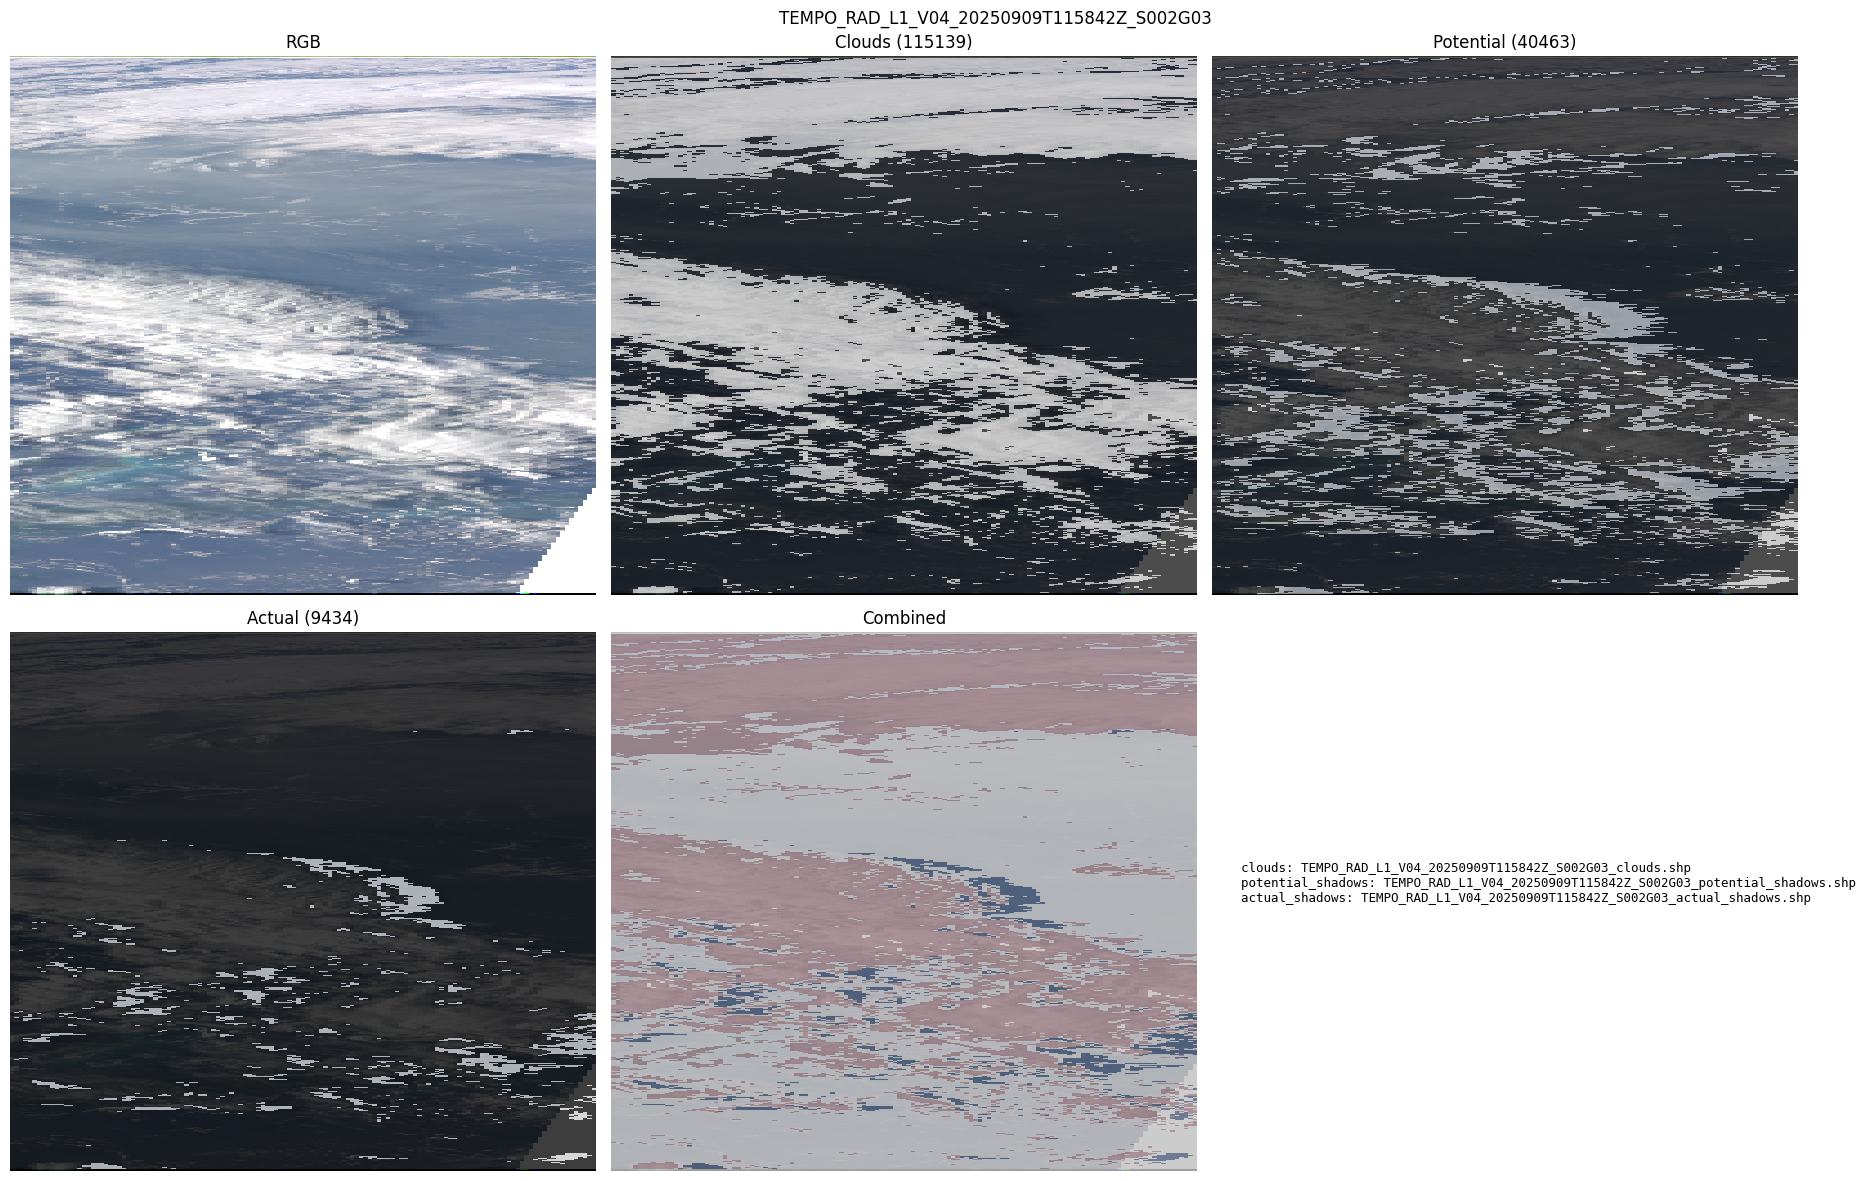


  3/4: TEMPO_RAD_L1_V04_20250909T125205Z_S003G05.nc
  Cloud fraction range: -999.000 to 1.000
  Drawing 101745 shadow lines...
  [height] dropped 3217/104962 source pixels (3.06%) without a valid cloud height
Loading geolocation data...
  Extent: [-99.32, 17.18, -88.24, 57.72]
    Cloud: 1174 polygons -> ../experiments/output_v3_vectorized_cthres0.3_helen_st0.05/TEMPO_RAD_L1_V04_20250909T125205Z_S003G05_clouds.shp
    Potential Shadow: 2720 polygons -> ../experiments/output_v3_vectorized_cthres0.3_helen_st0.05/TEMPO_RAD_L1_V04_20250909T125205Z_S003G05_potential_shadows.shp
    Actual Shadow: 679 polygons -> ../experiments/output_v3_vectorized_cthres0.3_helen_st0.05/TEMPO_RAD_L1_V04_20250909T125205Z_S003G05_actual_shadows.shp


/var/folders/0j/71sn2s2j71l6q088k8_ppzsc0000gn/T/ipykernel_3249/967298460.py:38: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf['area_deg2'] = gdf.geometry.area
/var/folders/0j/71sn2s2j71l6q088k8_ppzsc0000gn/T/ipykernel_3249/967298460.py:38: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf['area_deg2'] = gdf.geometry.area
/var/folders/0j/71sn2s2j71l6q088k8_ppzsc0000gn/T/ipykernel_3249/967298460.py:38: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf['area_deg2'] = gdf.geometry.area
/var/folders/0j/71sn2s2j71l6q088k8_ppzsc0000gn/T/ipykernel_3249/1211200630.py:202: RuntimeWarning

  Visualization: ../experiments/output_v3_vectorized_cthres0.3_helen_st0.05/TEMPO_RAD_L1_V04_20250909T125205Z_S003G05_visualization.png


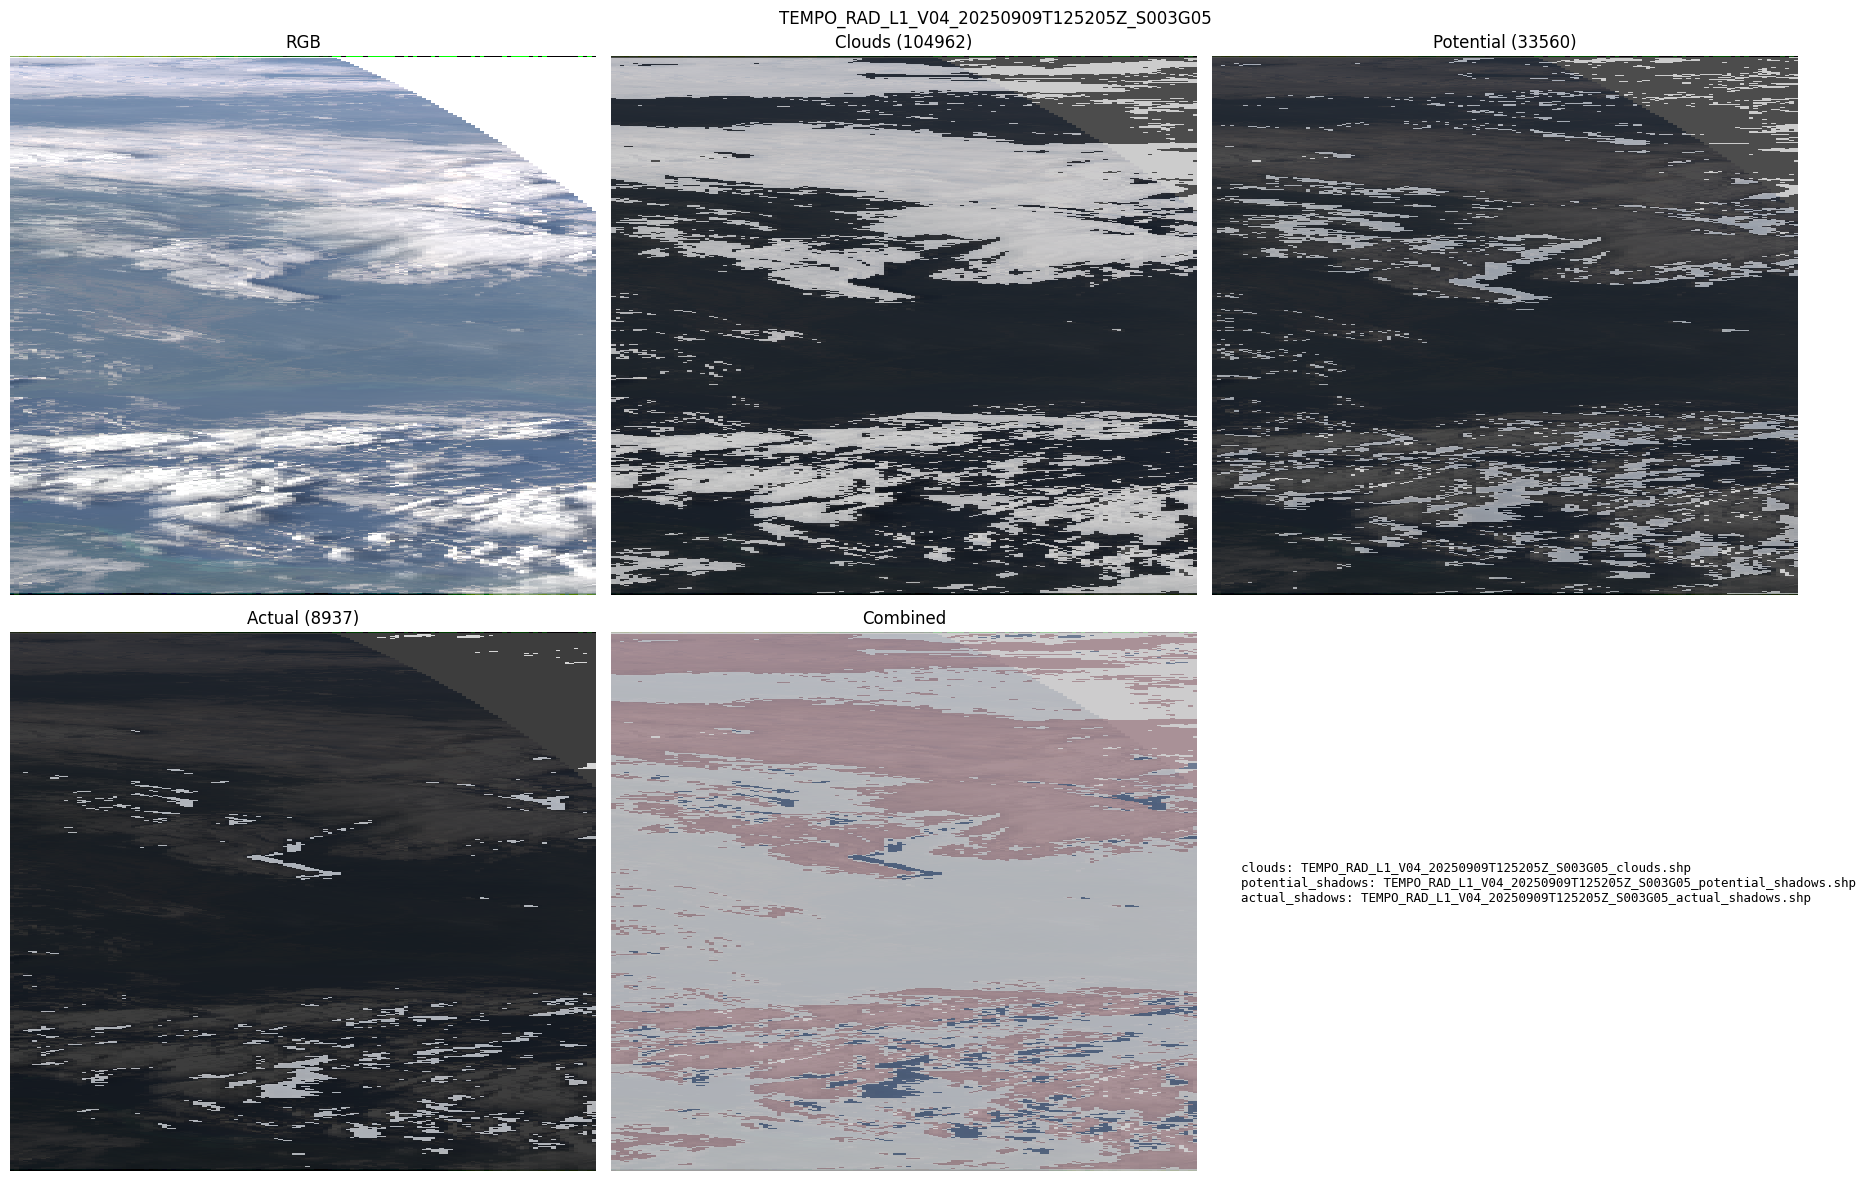


  4/4: TEMPO_RAD_L1_V04_20250909T231218Z_S014G02.nc
  Cloud fraction range: -999.000 to 1.000
  Drawing 88076 shadow lines...
  [height] dropped 4131/92207 source pixels (4.48%) without a valid cloud height
Loading geolocation data...
  Extent: [-99.26, 17.22, -88.11, 57.72]
    Cloud: 1473 polygons -> ../experiments/output_v3_vectorized_cthres0.3_helen_st0.05/TEMPO_RAD_L1_V04_20250909T231218Z_S014G02_clouds.shp
    Potential Shadow: 2720 polygons -> ../experiments/output_v3_vectorized_cthres0.3_helen_st0.05/TEMPO_RAD_L1_V04_20250909T231218Z_S014G02_potential_shadows.shp
    Actual Shadow: 640 polygons -> ../experiments/output_v3_vectorized_cthres0.3_helen_st0.05/TEMPO_RAD_L1_V04_20250909T231218Z_S014G02_actual_shadows.shp


/var/folders/0j/71sn2s2j71l6q088k8_ppzsc0000gn/T/ipykernel_3249/967298460.py:38: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf['area_deg2'] = gdf.geometry.area
/var/folders/0j/71sn2s2j71l6q088k8_ppzsc0000gn/T/ipykernel_3249/967298460.py:38: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf['area_deg2'] = gdf.geometry.area
/var/folders/0j/71sn2s2j71l6q088k8_ppzsc0000gn/T/ipykernel_3249/967298460.py:38: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf['area_deg2'] = gdf.geometry.area
/var/folders/0j/71sn2s2j71l6q088k8_ppzsc0000gn/T/ipykernel_3249/1211200630.py:202: RuntimeWarning

  Visualization: ../experiments/output_v3_vectorized_cthres0.3_helen_st0.05/TEMPO_RAD_L1_V04_20250909T231218Z_S014G02_visualization.png


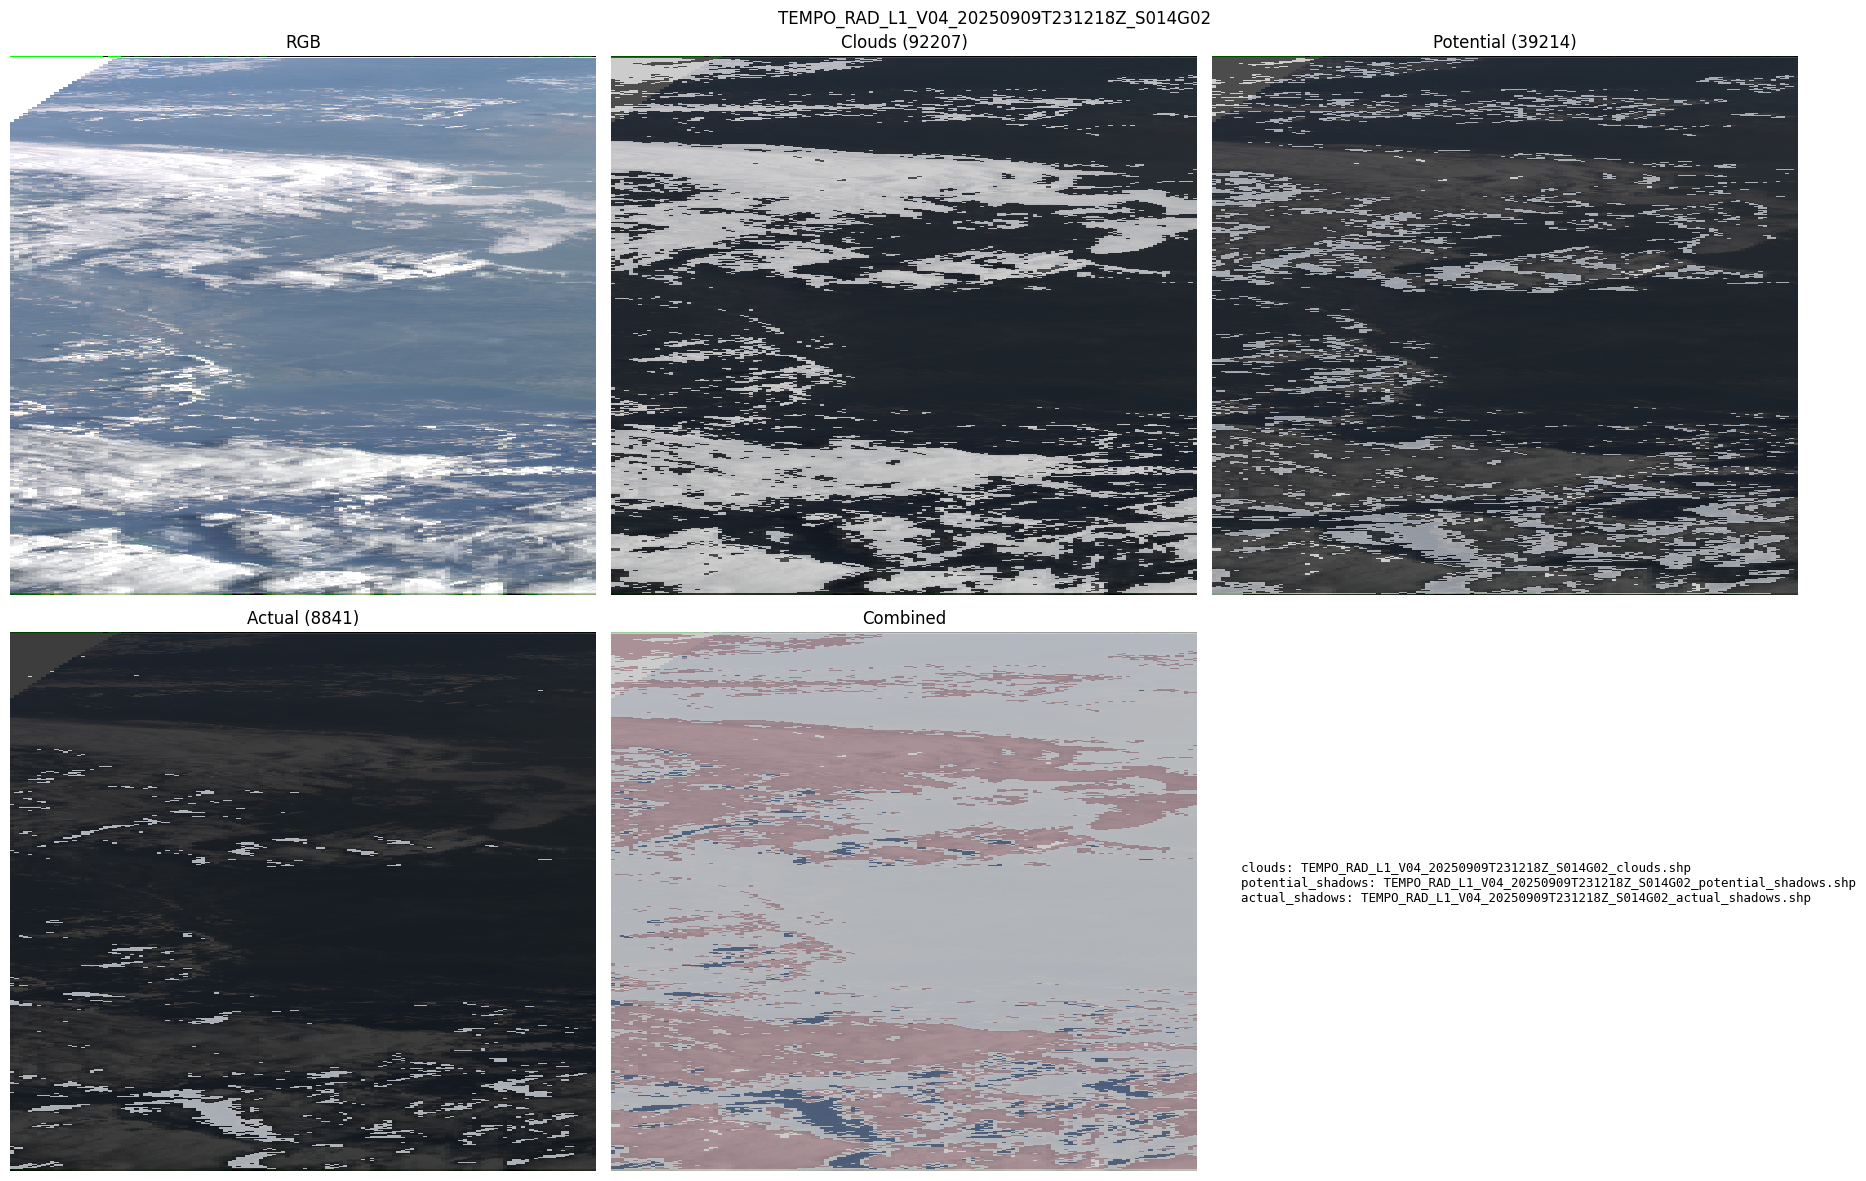

In [6]:
results = create_shadow_detection_pipeline_with_shapefiles(
    nc_files,
    l2_files,
    output_dir=output_dir,
    band=band,
    refinement=refinement,
    cloud_threshold=cloud_threshold,
    shadow_threshold=shadow_threshold,
    apply_gamma=True,
)